# SZR: Dopasowanie i wizualizacja
Ten notatnik ładuje dane populacji `S, Z, R` z symulacji, wczytuje dopasowane parametry modelu SZR i wizualizuje przebieg oraz jakość dopasowania.

In [2]:
# Konfiguracja i import bibliotek
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy import stats
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

In [19]:
# Wczytanie danych i parametrów dopasowania
repo_root = Path(".").resolve().parent  # repo root
# csv_path = repo_root / "notebooks" / "populations.csv"
csv_path = repo_root / "populacja5.csv"
params_path = repo_root / "notebooks" / "szr_params.json"
assert csv_path.exists(), f"Nie znaleziono CSV: {csv_path}"
assert params_path.exists(), f"Nie znaleziono pliku parametrów: {params_path}"

df = pd.read_csv(csv_path)
display(df.head())

with open(params_path, "r", encoding="utf-8") as f:
    params = json.load(f)
params

,time,S,Z,R,I
0,1,80,38,0,0
1,2,80,38,0,0
2,3,80,38,0,0
3,4,80,38,0,0
4,5,79,38,0,1


{'alpha': 0.006730670123385698,
 'beta': 0.3292028131232678,
 'gamma': 0.0966692517273283,
 'delta': 0.18781762996184725,
 'sse': 3189862.906797417}

In [ ]:
# Definicja modelu SZR
# dS/dt = -beta * S * Z / N + alpha * S + delta * Z
# dZ/dt =  beta * S * Z / N - gamma * Z - delta * Z
# dR/dt =  gamma * Z

def szr_rhs(_t, y, alpha, beta, gamma, delta):
    S, Z, R = y
    N = S + Z + R
    if N <= 1e-12:
        N = 1.0
    dS = -beta * S * Z / N + alpha * S + delta * Z
    dZ = beta * S * Z / N - gamma * Z - delta * Z
    dR = gamma * Z
    return (dS, dZ, dR)

def handwritten_model_rhs(t, y, beta, delta, rho, gamma, Lambda, K):
    """
    S: Podatni (Ludzie + Medycy + Żołnierze)
    I: Zarażeni (Infected - czekają na pomoc lub przemianę)
    Z: Zombie
    R: Usunięci (Martwi)
    
    Parametry:
    beta   - współczynnik infekcji
    delta  - skuteczność leczenia (I -> S)
    rho    - szybkość przemiany w zombie (I -> Z)
    gamma  - śmiertelność zombie (głód + żołnierze) (Z -> R)
    Lambda - współczynnik narodzin
    K      - pojemność środowiska (max liczba agentów na mapie)
    """
    S, I, Z, R = y
    
    # N to populacja żywa (bez martwych R)
    N = S + I + Z
    
    # Zabezpieczenie przed dzieleniem przez zero
    if N <= 1e-9: N = 1.0
    
    # --- RÓWNANIA Z KARTKI ---
    
    # 1. dS/dt
    # Logistic growth term: Lambda * S * (1 - N/K)
    births = Lambda * S * (1 - N/K)
    infection = beta * S * Z / N
    cured = delta * I
    
    dS = -infection + cured + births
    
    # 2. dI/dt
    # rho * I to przemiana w Zombie
    to_zombie = rho * I
    
    dI = infection - to_zombie - cured
    
    # 3. dZ/dt
    # gamma * Z to śmierć zombie
    zombie_death = gamma * Z
    
    dZ = to_zombie - zombie_death
    
    # 4. dR/dt
    dR = zombie_death
    
    return [dS, dI, dZ, dR]

# Przygotowanie czasu i warunków początkowych
t = df["time"].to_numpy(dtype=float)
Y = df[["S","Z","R"]].to_numpy(dtype=float)
y0 = Y[0]

# Stałe znane z symulacji (WPISZ SWOJE WARTOŚCI)
KNOWN_LAMBDA = 0.002
KNOWN_K = 128**2  # Przykładowa pojemność mapy
KNOWN_RHO = 1.0 / 80.0  # Przykład: infekcja trwa 20 klatek

# Symulacja z dopasowanymi parametrami
alpha = float(params["alpha"]) ; beta = float(params["beta"]) ; gamma = float(params["gamma"]) ; delta = float(params["delta"]) 
sol = solve_ivp(lambda tt, yy: handwritten_model_rhs(tt, yy, beta, delta, KNOWN_RHO, gamma, KNOWN_LAMBDA, KNOWN_K), t_span=(t[0], t[-1]), y0=y0, t_eval=t, rtol=1e-7, atol=1e-9)
assert sol.success, sol.message
Y_hat = sol.y.T  # shape (T, 3)
Y_hat[:5]

TypeError: handwritten_model_rhs() missing 2 required positional arguments: 'Lambda' and 'K'

In [12]:
# Obliczenie reszt i metryk RMSE, R^2
cols = ["S","Z","R"]
res = Y - Y_hat
sse = np.sum(res**2, axis=0)  # per series
n = Y.shape[0]

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

metrics = {}
for i, name in enumerate(cols):
    metrics[f"RMSE_{name}"] = rmse(Y[:, i], Y_hat[:, i])
    metrics[f"R2_{name}"] = r2(Y[:, i], Y_hat[:, i])

metrics["SSE_total"] = float(np.sum(sse))
metrics

{'RMSE_S': 10563.267798290148,
 'R2_S': -998934.4719204004,
 'RMSE_Z': 55.26251714320283,
 'R2_Z': -6.974170313594293,
 'RMSE_R': 1204.5991853406988,
 'R2_R': -31906.963800022215,
 'SSE_total': 113036739721.51807}

Saved: D:\Python\zombie-sim\fig\szr_fit_curve.png


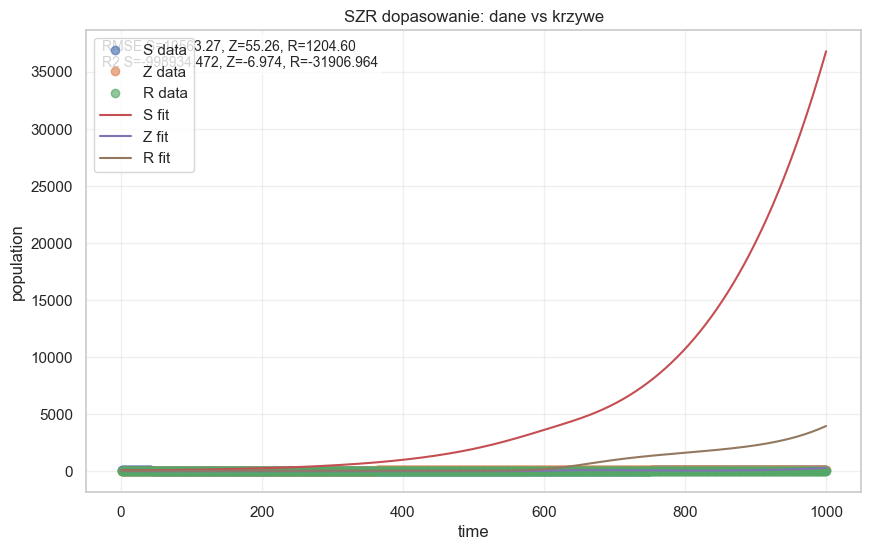

In [13]:
# Wykres danych i krzywej dopasowania
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ax.plot(t, Y[:,0], 'o', label='S data', alpha=0.65)
ax.plot(t, Y[:,1], 'o', label='Z data', alpha=0.65)
ax.plot(t, Y[:,2], 'o', label='R data', alpha=0.65)

ax.plot(t, Y_hat[:,0], '-', label='S fit')
ax.plot(t, Y_hat[:,1], '-', label='Z fit')
ax.plot(t, Y_hat[:,2], '-', label='R fit')
ax.set_xlabel('time')
ax.set_ylabel('population')
ax.set_title('SZR dopasowanie: dane vs krzywe')
ax.legend()
ax.grid(True, alpha=0.3)

# adnotacja metryk
txt = f"RMSE S={metrics['RMSE_S']:.2f}, Z={metrics['RMSE_Z']:.2f}, R={metrics['RMSE_R']:.2f}\nR2 S={metrics['R2_S']:.3f}, Z={metrics['R2_Z']:.3f}, R={metrics['R2_R']:.3f}"
ax.annotate(txt, xy=(0.02, 0.98), xycoords='axes fraction', va='top', ha='left', fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

out_dir = repo_root / 'fig'
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / 'szr_fit_curve.png'
fig.savefig(fig_path, dpi=150)
print('Saved:', fig_path)
plt.show()

--- ZNALEZIONE PARAMETRY ---
Beta (Infekcja): 0.02298
Rho  (Leczenie): 0.00693
Delta (Śmierć):  0.00085

--- WYNIKI DOPASOWANIA ---
S (Ludzie): RMSE=6.79, R2=0.5867
Z (Zombie): RMSE=18.79, R2=0.0781
R (Martwi): RMSE=16.30, R2=-4.8409


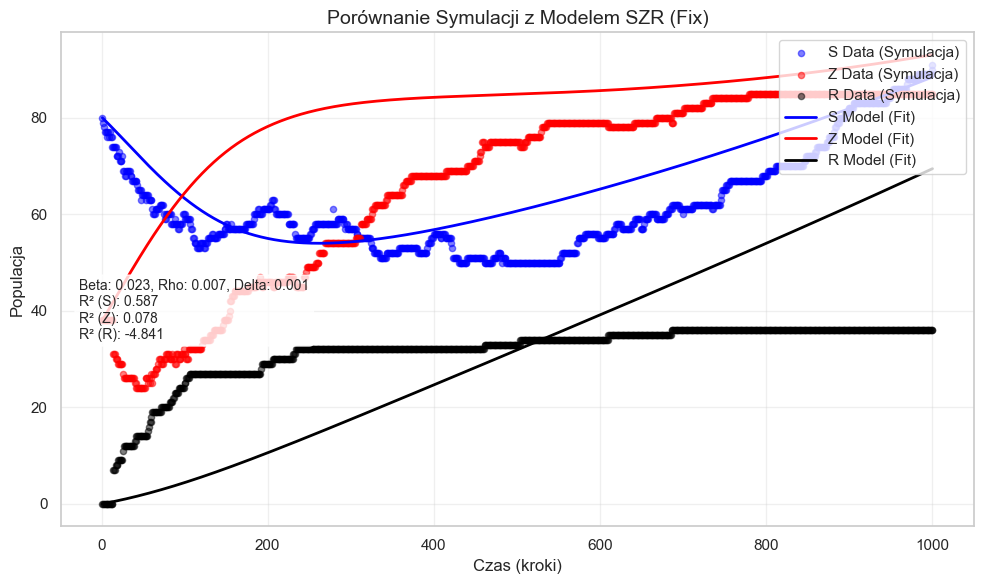

In [ ]:
from scipy.optimize import curve_fit
def simple_szr_fix(_t, y, alpha, beta, rho, delta):
    """
    alpha: narodziny ludzi (S)
    beta:  infekcja (S -> Z)
    rho:   leczenie przez medyka (Z -> S)  <-- To ratuje Infected
    delta: zabijanie przez żołnierza/głód (Z -> R)
    """
    S, Z, R = y
    N = S + Z + R
    if N <= 1e-12: N = 1.0
    
    # 1. Ludzie (S)
    # Przybywa: z narodzin (+alpha*S) ORAZ z wyleczenia (+rho*Z)
    # Ubywa: przez infekcję (-beta...)
    dS = alpha * S - beta * S * Z / N + rho * Z
    
    # 2. Zombie + Infected (Z)
    # Przybywa: z infekcji (+beta...)
    # Ubywa: bo wyleczeni (-rho*Z) LUB zabici (-delta*Z)
    dZ = beta * S * Z / N - rho * Z - delta * Z
    
    # 3. Usunięci (R)
    # Przybywa: tylko zabici Zombie
    dR = delta * Z
    
    return [dS, dZ, dR]

# 2. PRZYGOTOWANIE DANYCH
# Zakładamy, że masz już dataframe 'df'
t_data = df["time"].to_numpy(dtype=float)
S_data = df["S"].to_numpy(dtype=float)
Z_data = df["Z"].to_numpy(dtype=float) # Z tutaj to (Zombie + Infected)
R_data = df["R"].to_numpy(dtype=float)

# Warunki początkowe
y0 = [S_data[0], Z_data[0], R_data[0]]

# Znana wartość alpha - trzymamy ją stałą
KNOWN_ALPHA = 0.002

# 3. FUNKCJA DO DOPASOWANIA (WRAPPER)
def fit_func(t, beta, rho, delta):
    # Rozwiązujemy równanie dla zadanych parametrów
    sol = solve_ivp(
        fun=lambda tt, yy: simple_szr_fix(tt, yy, KNOWN_ALPHA, beta, rho, delta),
        t_span=(t[0], t[-1]),
        y0=y0,
        t_eval=t,
        rtol=1e-6
    )
    
    # Jeśli solver zawiedzie, zwracamy same zera (karę)
    if not sol.success or sol.y.shape[1] != len(t):
        return np.zeros(len(t) * 3)
        
    # Zwracamy spłaszczone dane [S1, S2..., Z1, Z2..., R1, R2...]
    # Ważne: Kolejność spłaszczania (transpose) musi być taka sama jak danych wejściowych
    return sol.y.T.flatten()

# Dane wejściowe spłaszczone do jednego wektora
y_data_flat = np.column_stack((S_data, Z_data, R_data)).flatten()

# 4. OPTYMALIZACJA (SZUKANIE PARAMETRÓW)
# Startujemy z losowych wartości [beta, rho, delta]
# Bounds: parametry muszą być > 0
popt, pcov = curve_fit(fit_func, t_data, y_data_flat, p0=[0.5, 0.1, 0.1], bounds=(0, np.inf))

best_beta, best_rho, best_delta = popt
print(f"--- ZNALEZIONE PARAMETRY ---")
print(f"Beta (Infekcja): {best_beta:.5f}")
print(f"Rho  (Leczenie): {best_rho:.5f}")
print(f"Delta (Śmierć):  {best_delta:.5f}")

# 5. GENEROWANIE KRZYWYCH MODELOWYCH DLA NAJLEPSZYCH PARAMETRÓW
sol_best = solve_ivp(
    fun=lambda tt, yy: simple_szr_fix(tt, yy, KNOWN_ALPHA, best_beta, best_rho, best_delta),
    t_span=(t_data[0], t_data[-1]),
    y0=y0,
    t_eval=t_data
)
S_model, Z_model, R_model = sol_best.y

# 6. OBLICZANIE METRYK (RMSE i R^2)
def calculate_metrics(y_true, y_pred):
    # RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    # R2
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    return rmse, r2

rmse_S, r2_S = calculate_metrics(S_data, S_model)
rmse_Z, r2_Z = calculate_metrics(Z_data, Z_model)
rmse_R, r2_R = calculate_metrics(R_data, R_model)

print(f"\n--- WYNIKI DOPASOWANIA ---")
print(f"S (Ludzie): RMSE={rmse_S:.2f}, R2={r2_S:.4f}")
print(f"Z (Zombie): RMSE={rmse_Z:.2f}, R2={r2_Z:.4f}")
print(f"R (Martwi): RMSE={rmse_R:.2f}, R2={r2_R:.4f}")

# 7. RYSOWANIE WYKRESU
fig, ax = plt.subplots(figsize=(10, 6))

# Rysowanie danych (kropki)
ax.scatter(t_data, S_data, color='blue', alpha=0.5, s=20, label='S Data (Symulacja)')
ax.scatter(t_data, Z_data, color='red', alpha=0.5, s=20, label='Z Data (Symulacja)')
ax.scatter(t_data, R_data, color='black', alpha=0.5, s=20, label='R Data (Symulacja)')

# Rysowanie modelu (linie ciągłe)
ax.plot(t_data, S_model, color='blue', linewidth=2, linestyle='-', label=f'S Model (Fit)')
ax.plot(t_data, Z_model, color='red', linewidth=2, linestyle='-', label=f'Z Model (Fit)')
ax.plot(t_data, R_model, color='black', linewidth=2, linestyle='-', label=f'R Model (Fit)')

# Dodatki wizualne
ax.set_title("Porównanie Symulacji z Modelem SZR (Fix)", fontsize=14)
ax.set_xlabel("Czas (kroki)")
ax.set_ylabel("Populacja")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Ramka z metrykami na wykresie
stats_text = (
    f"Beta: {best_beta:.3f}, Rho: {best_rho:.3f}, Delta: {best_delta:.3f}\n"
    f"R² (S): {r2_S:.3f}\n"
    f"R² (Z): {r2_Z:.3f}\n"
    f"R² (R): {r2_R:.3f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.02, 0.50, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

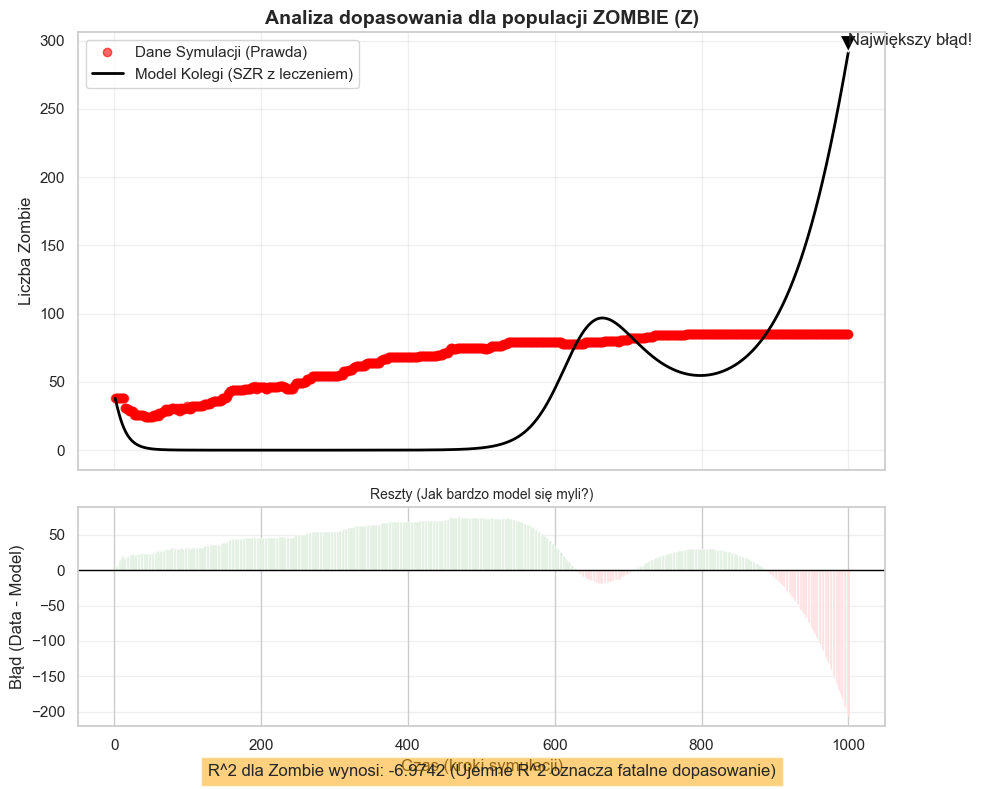

In [15]:
# --- 1. Przygotowanie danych (Z tylko dla Zombie) ---
t_data = df["time"].to_numpy()
z_data = df["Z"].to_numpy()     # Prawdziwe dane z symulacji
z_model = Y_hat[:, 1]           # Wynik modelu kolegi (kolumna 1 to Z)

# --- 2. Obliczenie reszt (błędu) ---
# Jeśli słupek idzie w górę -> Model zawyżył liczbę zombie
# Jeśli słupek idzie w dół -> Model zaniżył
residuals = z_data - z_model 

# --- 3. Rysowanie Wykresu Prawdy ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# GÓRNY WYKRES: Porównanie krzywych
ax1.set_title("Analiza dopasowania dla populacji ZOMBIE (Z)", fontsize=14, fontweight='bold')
ax1.plot(t_data, z_data, 'o', color='red', label='Dane Symulacji (Prawda)', alpha=0.6)
ax1.plot(t_data, z_model, '-', color='black', linewidth=2, label='Model Kolegi (SZR z leczeniem)')
ax1.set_ylabel("Liczba Zombie")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zaznaczenie obszaru największej rozbieżności (opcjonalne, automatyczne)
max_err_idx = np.argmax(np.abs(residuals))
ax1.annotate('Największy błąd!', xy=(t_data[max_err_idx], z_model[max_err_idx]), 
             xytext=(t_data[max_err_idx], z_model[max_err_idx]+5),
             arrowprops=dict(facecolor='black', shrink=0.05))

# DOLNY WYKRES: Wykres Błędu (Residuals)
colors = ['green' if r > 0 else 'red' for r in residuals]
ax2.bar(t_data, residuals, color=colors, alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Błąd (Data - Model)")
ax2.set_xlabel("Czas (kroki symulacji)")
ax2.set_title("Reszty (Jak bardzo model się myli?)", fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

# Dodanie informacji o R2 na wykresie
r2_z = metrics['R2_Z'] # Zakładam, że masz to policzone wcześniej
plt.figtext(0.5, 0.02, f"R^2 dla Zombie wynosi: {r2_z:.4f} (Ujemne R^2 oznacza fatalne dopasowanie)", 
            ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()

Saved: /home/rafal/Documents/GitHub/zombie-sim/fig/szr_residuals.png


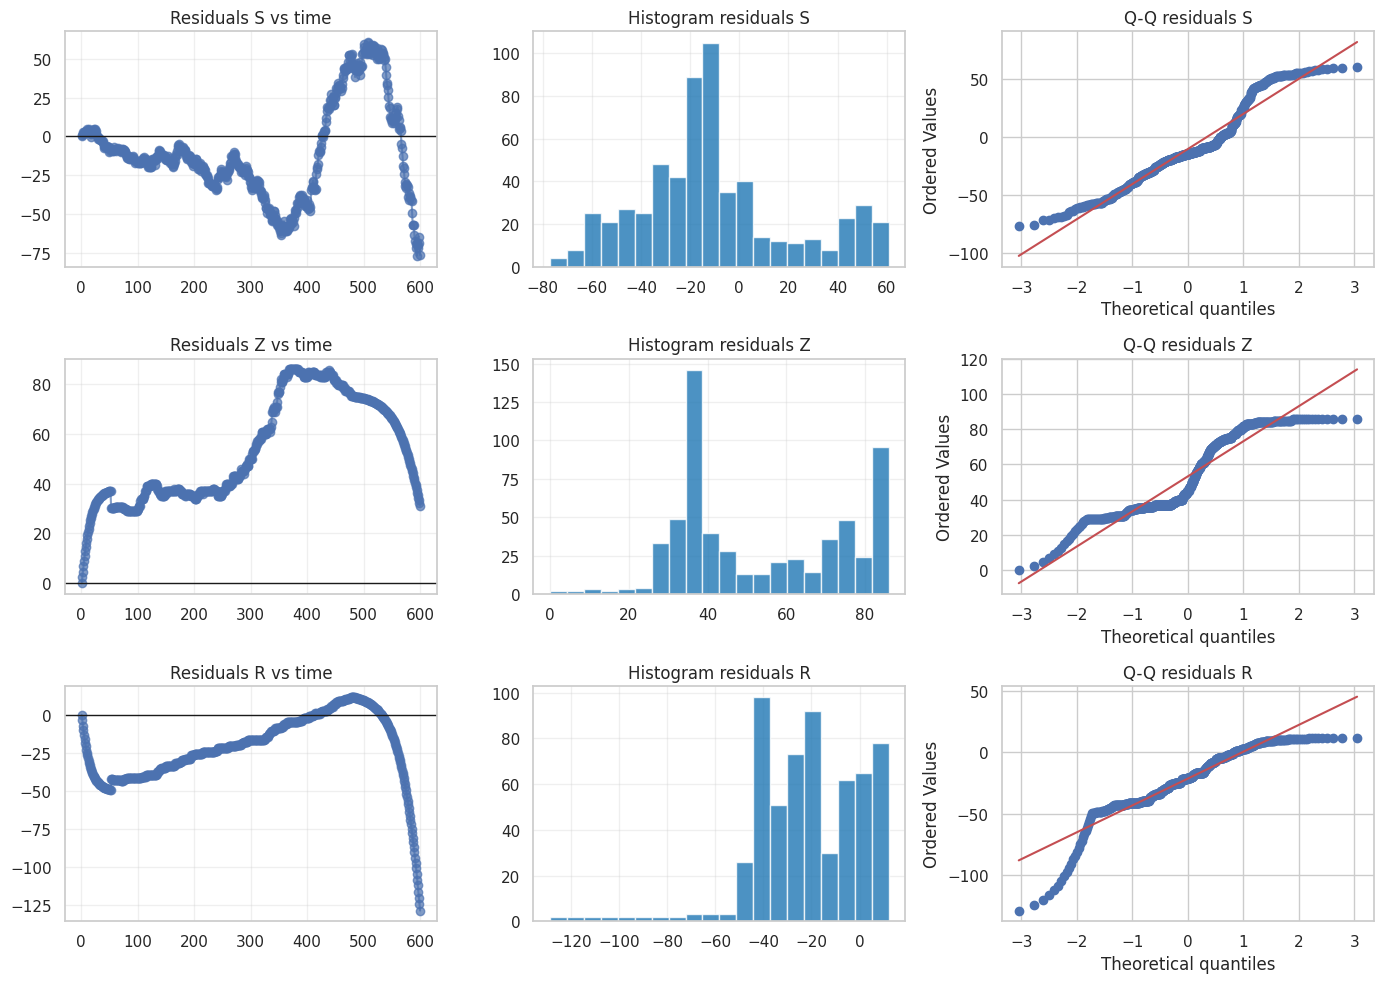

In [7]:
# Wykres reszt: serie S, Z, R
fig, axes = plt.subplots(3, 3, figsize=(14,10))
names = ['S','Z','R']
for i, name in enumerate(names):
    # reszty vs time
    axes[i,0].plot(t, res[:,i], 'o-', alpha=0.7)
    axes[i,0].axhline(0, color='k', lw=1)
    axes[i,0].set_title(f'Residuals {name} vs time')
    axes[i,0].grid(True, alpha=0.3)
    # histogram
    axes[i,1].hist(res[:,i], bins=20, alpha=0.8, color='tab:blue')
    axes[i,1].set_title(f'Histogram residuals {name}')
    axes[i,1].grid(True, alpha=0.3)
    # Q-Q plot
    stats.probplot(res[:,i], dist='norm', plot=axes[i,2])
    axes[i,2].set_title(f'Q-Q residuals {name}')
fig.tight_layout()
out_dir = repo_root / 'fig'
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / 'szr_residuals.png'
fig.savefig(fig_path, dpi=150)
print('Saved:', fig_path)
plt.show()

In [9]:
# Zapisywanie metryk i ścieżek do plików
results_dir = repo_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
metrics_path = results_dir / 'metrics_szr.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print('Saved metrics:', metrics_path)
list(results_dir.glob('*'))

Saved metrics: /home/rafal/Documents/GitHub/zombie-sim/results/metrics_szr.json


[PosixPath('/home/rafal/Documents/GitHub/zombie-sim/results/metrics_szr.json')]